# Contents

## 1. Importing libraries and data and trimming columns

Trimming columns


## 2. The elbow technique

Remove NaN values

Explanation

Silouhette Score

Explanation of Silhoutte Score


## 3. k-means clustering

Easier to interpret chart

Initial Interpretation

Review of Stats

Creation of new columns

New plot

## 4. Conclusion


## 5. Extra Review

Additional Insight

Preparing the dataframe for future use


## 1. Importing libraries and data

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.cluster import KMeans #Importing the k-means algorithm from scikit-learn.
import pylab as pl # PyLab is a convenience module that bulk imports matplotlib.

In [67]:
# This option ensures graphs are displayed in your notebook without the need to "call" them specifically.

%matplotlib inline

In [68]:
#Mount google drive

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
#Import data

df = pd.read_csv('/content/drive/MyDrive/test_Matches_Data_Clean_Post 1900.csv')

In [70]:
df.head()

,Match ID,Match Name,Start Date,End Date,Team 1,Innings 1 Team 1 Runs,Innings 1 Team 1 Wickets,Innings 1 Team 1 Extras,Innings 2 Team 1 Runs,Innings 2 Team 1 Wickets,...,Innings 2 Team 2 Runs,Innings 2 Team 2 Wickets,Innings 2 Team 2 Extras,Venue,City,Country,Toss Winner,Toss Winner Choice,Winner,Result
0,62387,Australia Vs South Africa,27/05/1912,28/05/1912,Australia,448,10,24,NaN,NaN,...,95.0,10.0,9.0,Old Trafford,Manchester,England,Australia,bat,Australia,Australia won by an innings and 88 runs
1,62388,England Vs South Africa,10/06/1912,12/06/1912,South Africa,58,10,17,217.0,10.0,...,NaN,NaN,NaN,Lord's,London,England,South Africa,bat,England,England won by an innings and 62 runs
2,62389,England Vs Australia,24/06/1912,26/06/1912,England,310,7,22,NaN,NaN,...,NaN,NaN,NaN,Lord's,London,England,England,bat,NaN,Match drawn
3,62390,England Vs South Africa,08/07/1912,10/07/1912,England,242,10,14,238.0,10.0,...,159.0,10.0,11.0,Headingley,Leeds,England,England,bat,England,England won by 174 runs
4,62391,Australia Vs South Africa,15/07/1912,17/07/1912,South Africa,263,10,29,173.0,10.0,...,48.0,0.0,1.0,Lord's,London,England,South Africa,bat,Australia,Australia won by 10 wickets


### Trimming columns

In [71]:
df_runs = df[['Innings 1 Team 1 Runs', 'Innings 1 Team 2 Runs', 'Innings 2 Team 1 Runs', 'Innings 2 Team 2 Runs']]

In [72]:
df_runs.head()

,Innings 1 Team 1 Runs,Innings 1 Team 2 Runs,Innings 2 Team 1 Runs,Innings 2 Team 2 Runs
0,448,265.0,NaN,95.0
1,58,337.0,217.0,NaN
2,310,282.0,NaN,NaN
3,242,147.0,238.0,159.0
4,263,390.0,173.0,48.0


### 2. The elbow technique

The elbow technique shows the point at which adding more clusters doesn't make your analysis any better.

You want enough clusters so that there's granualrity, you want few enough so that there's difference

In [73]:
num_cl = range(1, 10) # Defines the range of potential clusters in the data.
kmeans = [KMeans(n_clusters=i) for i in num_cl] # Defines k-means clusters in the range assigned above.

In [74]:
score = [kmeans[i].fit(df_runs).score(df_runs) for i in range(len(kmeans))] # Creates a score that represents
# a rate of variation for the given cluster option.

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

#Remove NaN

As in previous exercise, need to clean up data to remove NaNs - so first see how many we're dealing with

In [75]:
# Check for missing values

df_runs.isnull().sum()

,0
Innings 1 Team 1 Runs,0
Innings 1 Team 2 Runs,18
Innings 2 Team 1 Runs,317
Innings 2 Team 2 Runs,558


In [76]:
df_runs.shape

(2473, 4)

In [77]:
#Getting rid of the 4th innings Nans loses c 20% of the data, but I'm comfortable with that

df_runs = df_runs[df_runs['Innings 1 Team 1 Runs'].isnull() == False]
df_runs = df_runs[df_runs['Innings 1 Team 2 Runs'].isnull() == False]
df_runs = df_runs[df_runs['Innings 2 Team 1 Runs'].isnull() == False]
df_runs = df_runs[df_runs['Innings 2 Team 2 Runs'].isnull() == False]

In [78]:
# Check for missing values

df_runs.isnull().sum()

,0
Innings 1 Team 1 Runs,0
Innings 1 Team 2 Runs,0
Innings 2 Team 1 Runs,0
Innings 2 Team 2 Runs,0


In [79]:
df_runs.shape

#Still have over 1500 rows, which is the criterion for thsi exercise

(1679, 4)

Back to the elbow technique

In [80]:
score = [kmeans[i].fit(df_runs).score(df_runs) for i in range(len(kmeans))] # Creates a score that represents a rate of variation for the given cluster option.

In [81]:
score

[-81147610.01310308,
 -60988970.54283187,
 -48706276.19381386,
 -40339920.953822285,
 -35150866.8078922,
 -32410558.176229198,
 -30046101.878341436,
 -28232627.583651513,
 -26802737.057794288]

### Explanation

Including Co-pilot's explanation here for reference later on:


You're diving into a classic and very useful technique in unsupervised learning — the **elbow method** for determining the optimal number of clusters in **K-Means clustering**. Let's break down each line of your code and explain what it's doing:

---

### 🧮 Line 1: `num_cl = range(1, 10)`

- This creates a **range object** representing the integers from **1 to 9** (inclusive of 1, exclusive of 10).
- Each number in this range will represent a **different number of clusters** to try in the KMeans algorithm.

---

### 🔁 Line 2: `kmeans = [KMeans(n_clusters=i) for i in num_cl]`

- This is a **list comprehension** that creates a list of `KMeans` objects.
- For each value of `i` from 1 to 9, it creates a `KMeans` instance with `n_clusters=i`.
- So, `kmeans[0]` is a KMeans model with 1 cluster, `kmeans[1]` has 2 clusters, and so on up to 9 clusters.

---

### 📉 Line 3: `score = [kmeans[i].fit(df).score(df) for i in range(len(kmeans))]`

- This line fits each KMeans model to your dataset `df` and computes the **score** for each.
- `.fit(df)` trains the model on your data.
- `.score(df)` returns the **negative of the within-cluster sum of squares** (WCSS), also known as **inertia**.
  - Since it's negative, **lower values (closer to zero)** mean **better clustering**.
- The result is a list of scores (one for each number of clusters), which you can then **plot** to visualize the "elbow."

---

### 🧠 What's the "Elbow Method"?

- You plot the number of clusters (1 to 9) on the x-axis and the **negative score** (inertia) on the y-axis.
- The **"elbow point"** is where the rate of improvement sharply decreases — like an elbow in a bent arm.
- That point is often a good choice for the **optimal number of clusters**.


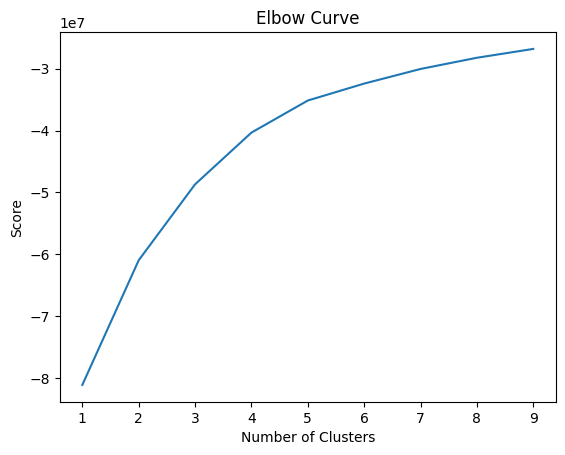

In [82]:
# Plot the elbow curve using PyLab.

pl.plot(num_cl,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

It's not a clear cut result, but based on this I would go with five.

I'm going to use another technique: Silhoutte Score method

### Silhoutte Score

Co-pilot explanation:
1. 📐 Silhouette Score Method
- Measures how similar a point is to its own cluster vs. other clusters.
- Ranges from -1 to 1: higher values mean better-defined clusters


In [83]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 10):  # silhouette score requires at least 2 clusters
    kmeans = KMeans(n_clusters=k).fit(df_runs)
    labels = kmeans.labels_
    sil_scores.append(silhouette_score(df_runs, labels))






#Co-pilot explanation of Silhoutte Score code

Absolutely — this snippet is calculating the **silhouette score** for different numbers of clusters in a KMeans clustering setup. Here's a breakdown of what each line does:

---

### 🧮 Line 1: `sil_scores = []`

- Initializes an empty list to store the **silhouette scores** for each clustering run.
- These scores will help you evaluate how well-separated and cohesive the clusters are.

---

### 🔁 Line 2: `for k in range(2, 10):`

- Loops through values of `k` from **2 to 9**, representing the number of clusters to try.
- Silhouette score requires **at least 2 clusters**, which is why the range starts at 2.

---

### ⚙️ Line 3: `kmeans = KMeans(n_clusters=k).fit(df)`

- Creates a KMeans model with `k` clusters and fits it to your dataset `df`.
- This step assigns each data point to one of the `k` clusters.

---

### 🏷️ Line 4: `labels = kmeans.labels_`

- Retrieves the **cluster labels** assigned to each data point by the fitted KMeans model.
- These labels are needed to calculate the silhouette score.

---

### 📐 Line 5: `sil_scores.append(silhouette_score(df, labels))`

- Computes the **silhouette score** for the current clustering configuration.
- Appends the score to the `sil_scores` list.
  - A **higher score** (closer to 1) means better-defined clusters.
  - A **lower score** (closer to -1) means poor clustering.

---

### 🧠 Summary

This loop helps you evaluate how well your data clusters for different values of `k`. Once you have the `sil_scores` list, you can plot it to find the number of clusters that gives the **highest silhouette score**, which is often a good candidate for the optimal number of clusters.



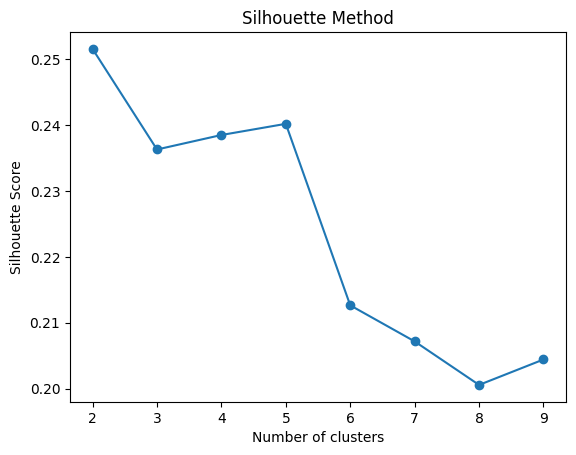

In [84]:
# Plot silhouette scores
plt.plot(range(2, 10), sil_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

It's now much more obvious that 5 is the correct number of clusters

# 3. k-means clustering

In [85]:
# Create the k-means object.

kmeans = KMeans(n_clusters = 5)

In [86]:
# Fit the k-means object to the data.

kmeans.fit(df_runs)

KMeans(n_clusters=5)

In [87]:
#Add a new column to contain the clusters

df_runs['clusters'] = kmeans.fit_predict(df_runs)

In [88]:
df_runs.head()

,Innings 1 Team 1 Runs,Innings 1 Team 2 Runs,Innings 2 Team 1 Runs,Innings 2 Team 2 Runs,clusters
3,242,147.0,238.0,159.0,1
4,263,390.0,173.0,48.0,4
7,95,176.0,93.0,14.0,4
8,245,111.0,175.0,65.0,4
10,112,61.0,353.0,175.0,3


In [89]:
df_runs['clusters'].value_counts()

,count
clusters,
4,378
3,333
1,330
0,322
2,316


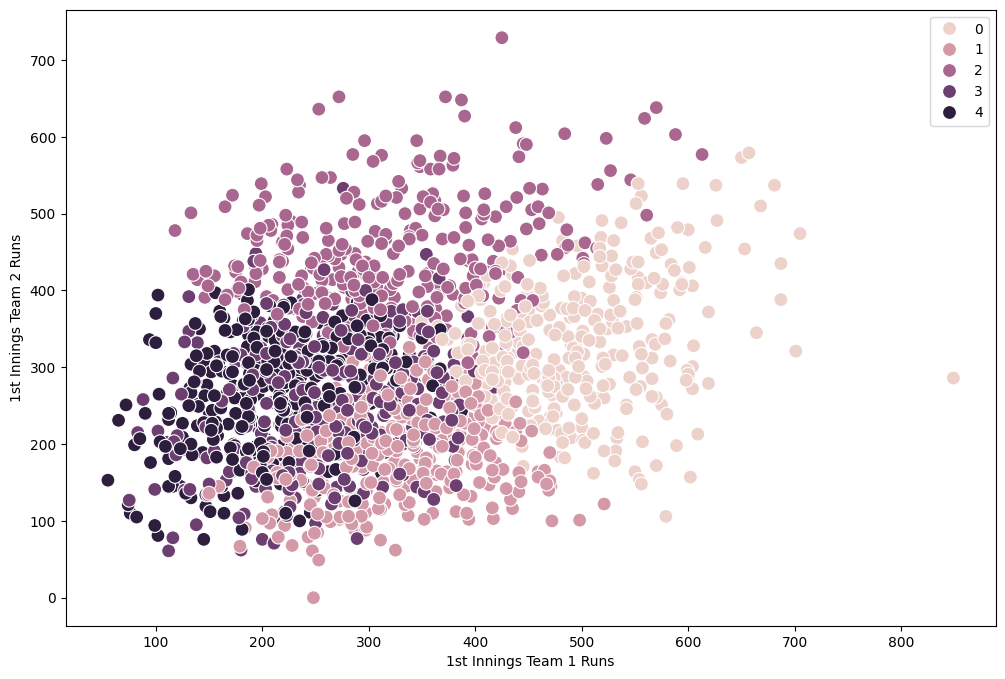

In [90]:
# Plot the clusters for the "Innings 1 Team 1 Runs" and "Innings 1 Team 2 Runs" variables.

plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df_runs['Innings 1 Team 1 Runs'], y=df_runs['Innings 1 Team 2 Runs'], hue=kmeans.labels_, s=100)
# Here, you're subsetting `X` for the x and y arguments to avoid using their labels.
# `hue` takes the value of the attribute `kmeans.labels_`, which is the result of running the k-means algorithm.
# `s` represents the size of the points you want to see in the plot.

ax.grid(False) # This removes the grid from the background.
plt.xlabel('1st Innings Team 1 Runs') # Label x-axis.
plt.ylabel('1st Innings Team 2 Runs') # Label y-axis.
plt.show()

### Easier to interpret chart

The colours and size of the plot points make this a bit hard to interpret - so will try to work on that.

In [91]:
# Define my own color list
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']


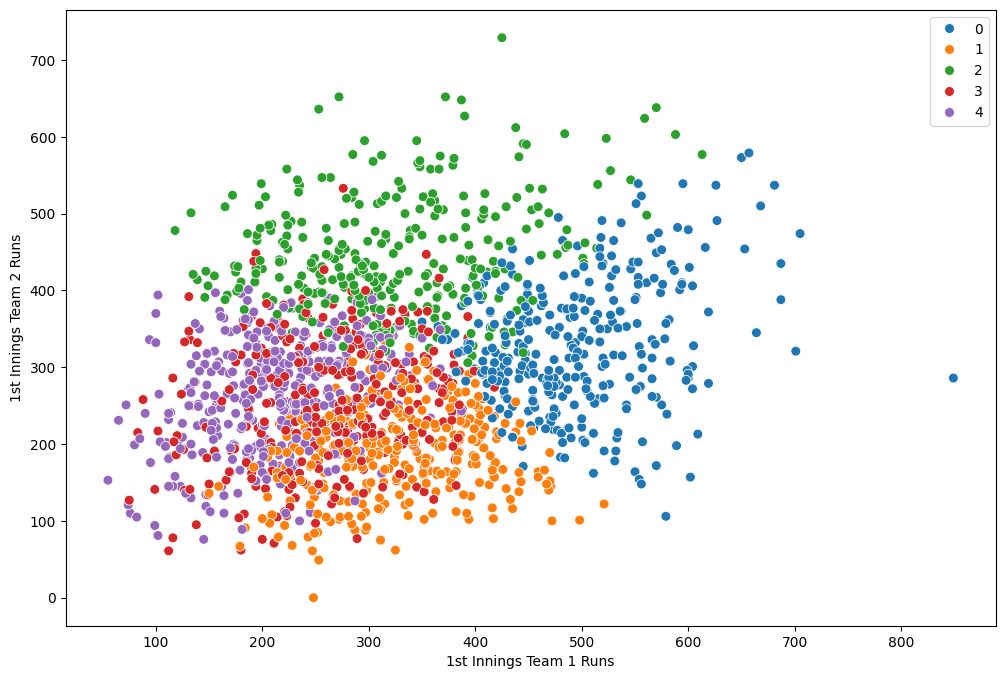

In [92]:
plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df_runs['Innings 1 Team 1 Runs'], y=df_runs['Innings 1 Team 2 Runs'], hue=kmeans.labels_, palette=custom_colors,
 s=50)
#Set palette to custom colours
# reduce point size

ax.grid(False) # This removes the grid from the background.
plt.xlabel('1st Innings Team 1 Runs') # Label x-axis.
plt.ylabel('1st Innings Team 2 Runs') # Label y-axis.
plt.show()

### Initial Interpretation

That's really helped.

Can now see that we have - broadly:
Red - both teams score highly
Green - both teams score lowly
Blue: team 1 scores high, team 2 low
Orange: team 2 scores high, team 1 low

We might think purpple indicates average scores, but it overlaps with green and a little with orange. So something else is going on.

Perhaps looking at the stats would help


### Review of stats

In [93]:
#Renaming the clusters

df_runs.loc[df_runs['clusters'] == 0, 'cluster'] = 'blue'
df_runs.loc[df_runs['clusters'] == 1, 'cluster'] = 'orange'
df_runs.loc[df_runs['clusters'] == 2, 'cluster'] = 'green'
df_runs.loc[df_runs['clusters'] == 3, 'cluster'] = 'red'
df_runs.loc[df_runs['clusters'] == 4, 'cluster'] = 'purple'


In [94]:
#Looking at the stats

df_runs.groupby('cluster').agg({'Innings 1 Team 1 Runs':['mean', 'median'],
                         'Innings 1 Team 2 Runs':['mean', 'median'],
                         'Innings 2 Team 1 Runs':['mean', 'median'],
                          'Innings 2 Team 2 Runs':['mean', 'median']})

Innings 1 Team 1 Runs        Innings 1 Team 2 Runs         \
                         mean median                  mean median   
cluster                                                             
blue               495.900621  487.0            329.618012  321.0   
green              323.079114  316.0            444.636076  430.5   
orange             328.772727  328.0            188.690909  189.5   
purple             213.894180  214.0            264.452381  269.0   
red                263.297297  269.0            253.645646  252.0   

        Innings 2 Team 1 Runs        Innings 2 Team 2 Runs         
                         mean median                  mean median  
cluster                                                            
blue               205.031056  210.5            249.897516  241.5  
green              287.996835  280.5             96.417722   95.0  
orange             193.084848  208.5            224.609091  219.0  
purple             197.121693  192.5            100.682540  101.5  
red                380.120120  363.0            246.417417  242.0

### Creation of new columns

In [95]:
# That's not very clear. Going to concentrate just on mean
#Also going to look at totals of Innings 1, Innnings 1, Team 1, Team 2 and the whole match

df_runs['Innings 1 Runs'] = df_runs['Innings 1 Team 1 Runs'] + df_runs['Innings 1 Team 2 Runs']
df_runs['Innings 2 Runs'] = df_runs['Innings 2 Team 1 Runs'] + df_runs['Innings 2 Team 2 Runs']
df_runs['Team 1 Runs'] = df_runs['Innings 1 Team 1 Runs'] + df_runs['Innings 2 Team 1 Runs']
df_runs['Team 2 Runs'] = df_runs['Innings 1 Team 2 Runs'] + df_runs['Innings 2 Team 2 Runs']
df_runs['Total Runs'] = df_runs['Innings 1 Runs'] + df_runs['Innings 2 Runs']

In [96]:
#Looking at the means only

df_runs.groupby('cluster').agg({'Innings 1 Team 1 Runs':['mean'],
                         'Innings 1 Team 2 Runs':['mean'],
                         'Innings 2 Team 1 Runs':['mean'],
                          'Innings 2 Team 2 Runs':['mean'],
                                'Innings 1 Runs':['mean'],
                                'Innings 2 Runs':['mean'],
                                'Team 1 Runs':['mean'],
                                'Team 2 Runs':['mean'],
                                'Total Runs':['mean']})

,Innings 1 Team 1 Runs,Innings 1 Team 2 Runs,Innings 2 Team 1 Runs,Innings 2 Team 2 Runs,Innings 1 Runs,Innings 2 Runs,Team 1 Runs,Team 2 Runs,Total Runs
,mean,mean,mean,mean,mean,mean,mean,mean,mean
cluster,,,,,,,,,
blue,495.900621,329.618012,205.031056,249.897516,825.518634,454.928571,700.931677,579.515528,1280.447205
green,323.079114,444.636076,287.996835,96.417722,767.715190,384.414557,611.075949,541.053797,1152.129747
orange,328.772727,188.690909,193.084848,224.609091,517.463636,417.693939,521.857576,413.300000,935.157576
purple,213.894180,264.452381,197.121693,100.682540,478.346561,297.804233,411.015873,365.134921,776.150794
red,263.297297,253.645646,380.120120,246.417417,516.942943,626.537538,643.417417,500.063063,1143.480480


That does help - certainly to understand purple.

Purple is when the 2nd innings has bigger scores than the 1st

Let's plot that to show what we emean

### New plot

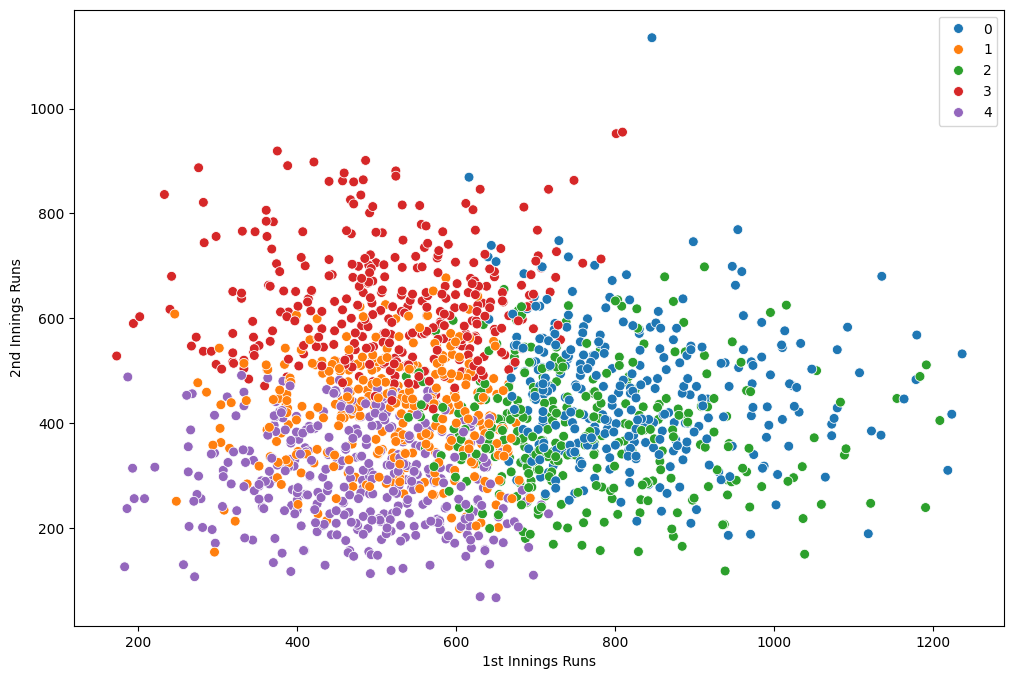

In [97]:
plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df_runs['Innings 1 Runs'], y=df_runs['Innings 2 Runs'], hue=kmeans.labels_, palette=custom_colors,
 s=50)
#Set palette to custom colours
# reduce point size

ax.grid(False) # This removes the grid from the background.
plt.xlabel('1st Innings Runs') # Label x-axis.
plt.ylabel('2nd Innings Runs') # Label y-axis.
plt.show()

Now purple sits as a clearer cluster - with 2nd innings > 1st innings

# 4. Conclusion:

This allows us to think about test innings in a different way.

Most often, more runs are scored in the 1st innings, and in this instance, there are four scenarios:
*   Red: both teams score highly
*   Orange: both teamd score lowly
*   Green: team batting first dominates
*  Blue: team batting second dominates

But there is an exception to this - when more runs are scored in the second innings, and then the game runs quite differently - this is Purple.

It will be useful to apply these clusters in future analysis.

# 5. Extra Review

Looking at the data to see if 4 clusters would be just as interesting

In [98]:
# Create the k-means object.

kmeans2 = KMeans(n_clusters = 4)

In [99]:
# Fit the k-means object to the data.

kmeans2.fit(df_runs)

ValueError: could not convert string to float: 'orange'

Of course - the df now includes the other clusters

In [100]:
#Drop the 'Cluster' column

df_runs2 = df_runs.drop('cluster', axis=1)

In [101]:
df_runs2.head()

,Innings 1 Team 1 Runs,Innings 1 Team 2 Runs,Innings 2 Team 1 Runs,Innings 2 Team 2 Runs,clusters,Innings 1 Runs,Innings 2 Runs,Team 1 Runs,Team 2 Runs,Total Runs
3,242,147.0,238.0,159.0,1,389.0,397.0,480.0,306.0,786.0
4,263,390.0,173.0,48.0,4,653.0,221.0,436.0,438.0,874.0
7,95,176.0,93.0,14.0,4,271.0,107.0,188.0,190.0,378.0
8,245,111.0,175.0,65.0,4,356.0,240.0,420.0,176.0,596.0
10,112,61.0,353.0,175.0,3,173.0,528.0,465.0,236.0,701.0


In [102]:
# Fit the k-means object to the data.

kmeans2.fit(df_runs2)

KMeans(n_clusters=4)

In [103]:
#Add a new column to contain the clusters

df_runs2['cluster2'] = kmeans2.fit_predict(df_runs2)

In [104]:
df_runs2.head()

,Innings 1 Team 1 Runs,Innings 1 Team 2 Runs,Innings 2 Team 1 Runs,Innings 2 Team 2 Runs,clusters,Innings 1 Runs,Innings 2 Runs,Team 1 Runs,Team 2 Runs,Total Runs,cluster2
3,242,147.0,238.0,159.0,1,389.0,397.0,480.0,306.0,786.0,0
4,263,390.0,173.0,48.0,4,653.0,221.0,436.0,438.0,874.0,1
7,95,176.0,93.0,14.0,4,271.0,107.0,188.0,190.0,378.0,0
8,245,111.0,175.0,65.0,4,356.0,240.0,420.0,176.0,596.0,0
10,112,61.0,353.0,175.0,3,173.0,528.0,465.0,236.0,701.0,0


In [105]:
df_runs2['cluster2'].value_counts()

,count
cluster2,
0,513
1,461
2,389
3,316


/tmp/ipython-input-1152976736.py:2: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.scatterplot(x=df_runs2['Innings 1 Team 1 Runs'], y=df_runs2['Innings 1 Team 2 Runs'], hue=kmeans2.labels_, palette=custom_colors,


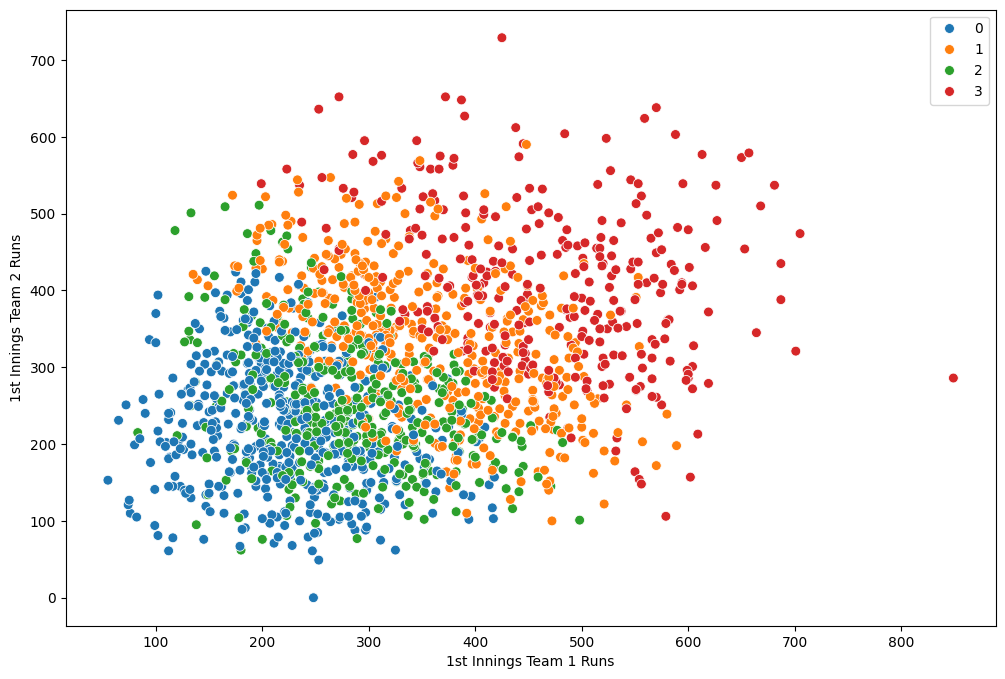

In [106]:
plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df_runs2['Innings 1 Team 1 Runs'], y=df_runs2['Innings 1 Team 2 Runs'], hue=kmeans2.labels_, palette=custom_colors,
 s=50)
#Set palette to custom colours
# reduce point size

ax.grid(False) # This removes the grid from the background.
plt.xlabel('1st Innings Team 1 Runs') # Label x-axis.
plt.ylabel('1st Innings Team 2 Runs') # Label y-axis.
plt.show()

That appears to have confused matters - there are now lots of overlaps between clusters

/tmp/ipython-input-3775379776.py:4: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.scatterplot(x=df_runs2['Innings 1 Runs'], y=df_runs2['Innings 2 Runs'], hue=kmeans2.labels_, palette=custom_colors,


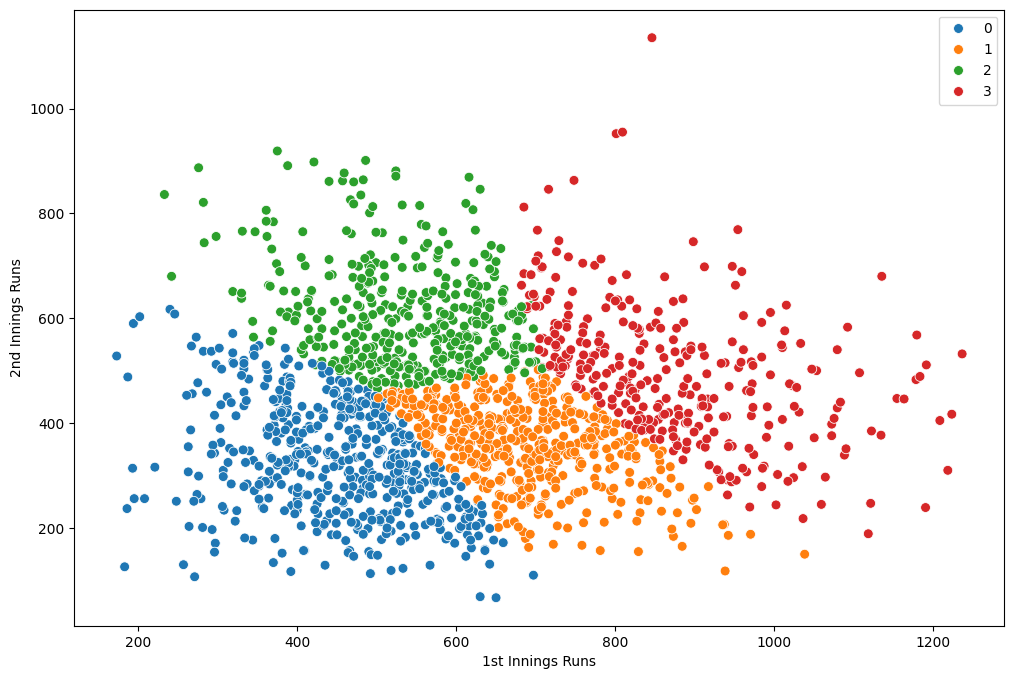

In [107]:
#Try on Innings Runs

plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df_runs2['Innings 1 Runs'], y=df_runs2['Innings 2 Runs'], hue=kmeans2.labels_, palette=custom_colors,
 s=50)
#Set palette to custom colours
# reduce point size

ax.grid(False) # This removes the grid from the background.
plt.xlabel('1st Innings Runs') # Label x-axis.
plt.ylabel('2nd Innings Runs') # Label y-axis.
plt.show()


That's VERY clear - and useful

/tmp/ipython-input-3846195114.py:4: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.scatterplot(x=df_runs2['Team 1 Runs'], y=df_runs2['Team 2 Runs'], hue=kmeans2.labels_, palette=custom_colors,


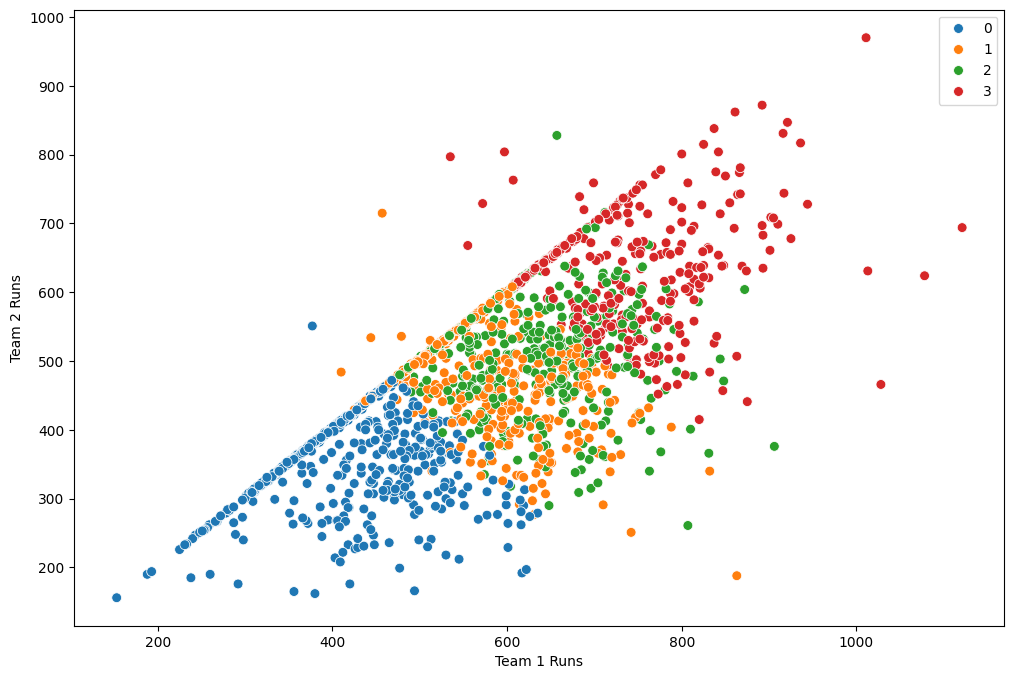

In [108]:
#Try on Team Runs

plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df_runs2['Team 1 Runs'], y=df_runs2['Team 2 Runs'], hue=kmeans2.labels_, palette=custom_colors,
 s=50)
#Set palette to custom colours
# reduce point size

ax.grid(False) # This removes the grid from the background.
plt.xlabel('Team 1 Runs') # Label x-axis.
plt.ylabel('Team 2 Runs') # Label y-axis.
plt.show()

In [109]:
#THat's just a bit weird - let's look at stats

df_runs2.groupby('cluster2').agg({
                                'Team 1 Runs':['mean', 'median'],
                                'Team 2 Runs':['mean', 'median']})

Team 1 Runs        Team 2 Runs       
                mean median        mean median
cluster2                                      
0         420.487329  419.0  356.031189  365.0
1         571.776573  569.0  477.095445  483.0
2         636.053985  635.0  506.262211  511.0
3         740.224684  732.0  629.705696  631.0

In [110]:
#Look at a few values

df_runs2[['Team 1 Runs', 'Team 2 Runs']].head(20)

,Team 1 Runs,Team 2 Runs
3,480.0,306.0
4,436.0,438.0
7,188.0,190.0
8,420.0,176.0
10,465.0,236.0
11,635.0,636.0
12,416.0,420.0
13,399.0,367.0
16,483.0,340.0
17,385.0,382.0


This has revealed what's going on, to win the match, teams only need to score one more run than the other - so quite frequently their total scores will be very close. A simple scatterplot would show that.

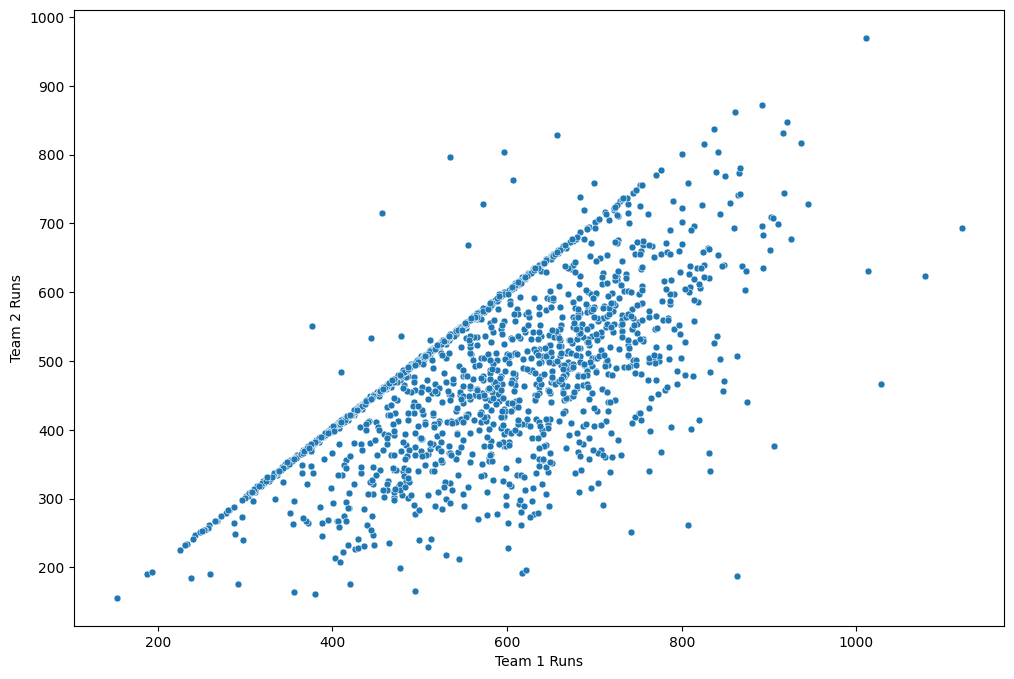

In [111]:
#Scatterplot of 'Team 1 Runs' vs 'Team 2 Runs'

plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df_runs2['Team 1 Runs'], y=df_runs2['Team 2 Runs'], s=25)

#### Aditional Insight

This is now much clearer to me.

In many instances the Team 2 wins by "wickets" i.e. they chase team 1's total and get 1 or more run than the opposition with wickets in hand. Therefore, the total number of runs scored by each team is very similar, This is our straight diagonal line.


Otherwise, Team 1s total is unassailable, and Team 2 runs out of wickets before they can cath them. Thesea re the instances below the diagonal.

In just a few instances the team batting 2nd scores so may runs in their first innings (or have "followed on" - batted a second tine), that even with a second innings, Team 1 cannot catch them. These are the instances above the diagonal.

This is probaly not useful for further analysis - bit will help understand future analysis.

### Preparing the dataframe for future use

In [112]:
#Adding the column 'cluster2' from df_runs2 to df_runs - in case it's useful

df_runs['cluster2'] = df_runs2['cluster2']


In [113]:
df_runs.head()

,Innings 1 Team 1 Runs,Innings 1 Team 2 Runs,Innings 2 Team 1 Runs,Innings 2 Team 2 Runs,clusters,cluster,Innings 1 Runs,Innings 2 Runs,Team 1 Runs,Team 2 Runs,Total Runs,cluster2
3,242,147.0,238.0,159.0,1,orange,389.0,397.0,480.0,306.0,786.0,0
4,263,390.0,173.0,48.0,4,purple,653.0,221.0,436.0,438.0,874.0,1
7,95,176.0,93.0,14.0,4,purple,271.0,107.0,188.0,190.0,378.0,0
8,245,111.0,175.0,65.0,4,purple,356.0,240.0,420.0,176.0,596.0,0
10,112,61.0,353.0,175.0,3,red,173.0,528.0,465.0,236.0,701.0,0


In [114]:
#drop the 'clusters' column

df_runs = df_runs.drop('clusters', axis=1)



In [115]:
df_runs.loc[df_runs['cluster'] == 'blue', 'cluster'] = 'Team 2 Dominates'
df_runs.loc[df_runs['cluster'] == 'orange', 'cluster'] = 'Low Scoring Game'
df_runs.loc[df_runs['cluster'] == 'green', 'cluster'] = 'Team 1 Dominates'
df_runs.loc[df_runs['cluster'] == 'red', 'cluster'] = 'High Scoring Games'
df_runs.loc[df_runs['cluster'] == 'purple', 'cluster'] = '2nd Innings Higher Scoring'

In [116]:
df_runs.head()

,Innings 1 Team 1 Runs,Innings 1 Team 2 Runs,Innings 2 Team 1 Runs,Innings 2 Team 2 Runs,cluster,Innings 1 Runs,Innings 2 Runs,Team 1 Runs,Team 2 Runs,Total Runs,cluster2
3,242,147.0,238.0,159.0,Low Scoring Game,389.0,397.0,480.0,306.0,786.0,0
4,263,390.0,173.0,48.0,2nd Innings Higher Scoring,653.0,221.0,436.0,438.0,874.0,1
7,95,176.0,93.0,14.0,2nd Innings Higher Scoring,271.0,107.0,188.0,190.0,378.0,0
8,245,111.0,175.0,65.0,2nd Innings Higher Scoring,356.0,240.0,420.0,176.0,596.0,0
10,112,61.0,353.0,175.0,High Scoring Games,173.0,528.0,465.0,236.0,701.0,0


This now gives me a "flag" for the type of game. More sensible to rename as such

In [119]:
# Rename 'cluster'

df_runs = df_runs.rename(columns={'cluster': 'Match Type'})

In [120]:
df_runs.head()

,Innings 1 Team 1 Runs,Innings 1 Team 2 Runs,Innings 2 Team 1 Runs,Innings 2 Team 2 Runs,Game Type,Innings 1 Runs,Innings 2 Runs,Team 1 Runs,Team 2 Runs,Total Runs,cluster2
3,242,147.0,238.0,159.0,Low Scoring Game,389.0,397.0,480.0,306.0,786.0,0
4,263,390.0,173.0,48.0,2nd Innings Higher Scoring,653.0,221.0,436.0,438.0,874.0,1
7,95,176.0,93.0,14.0,2nd Innings Higher Scoring,271.0,107.0,188.0,190.0,378.0,0
8,245,111.0,175.0,65.0,2nd Innings Higher Scoring,356.0,240.0,420.0,176.0,596.0,0
10,112,61.0,353.0,175.0,High Scoring Games,173.0,528.0,465.0,236.0,701.0,0


So I now have my "Match Type" as well as my other cluster, in case that proves useful down the line.

In [121]:
#Download df_runs to Google drive as csv

df_runs.to_csv('df_runs.csv')



